In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from core.signal.preprocess import *
from glob import glob
import torchaudio
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.signal import *
import core.nn.utils
import os
import torchinfo
import core.nn.VCTK
import torchvision.transforms

In [2]:
import logging
# fix seed for reproducibility
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
logging.basicConfig(level=logging.INFO)

In [26]:
Fs = 16000

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
groundTruthConfig = {
    "root": "vctk/",
    "download": False,
}
sensorConfig = {
    "root": "MICEMOUSE\gen\csv",
    "Fs": Fs,
    "device": device,
    "resampleMethod": 'sinc'
}

paired_ds = core.nn.VCTK.PairedAudioDataset(groundTruthConfig, sensorConfig)
filtered_paired_ds = core.nn.VCTK.removeOutliers(paired_ds)
train_loader, test_loader, dev_loader = core.nn.VCTK.getAudioLoaders(filtered_paired_ds, device = device, batch_size=32)

INFO:root:Initializing PairedAudioDataset...


Removed 1387 outliers 3.16% of the dataset
Remaining 43873 samples
Train: 1129 batches = 36128 samples
Test: 166 batches = 5312 samples
Dev: 34 batches = 1088 samples


In [4]:
import whisper
perceptualEmbedding = whisper.load_model("tiny").encoder.to(device)
perceptualEmbedding.eval()
for p in perceptualEmbedding.parameters():
    p.requires_grad = False

In [5]:
from math import ceil
_, Xnoise, Ynoise = processFromFile("vctk\\gen\\noise\\noise_2023-11-03_21-00-40.csv", method='sinc')
# Pad to closest 16000
Fs = 16000
noise = F.pad((Xnoise+Ynoise)/2, (0, ceil((Xnoise.shape[0] / (5 * Fs)))*(5 * Fs) - Xnoise.shape[0]), "constant", 0)
noise = noise.reshape(-1, 5 * Fs)

In [6]:
# compute FFT in dev set
Data_PSD = []
Noisy_PSD = []
for Xorig, Yorig in tqdm(dev_loader):
    # Get FFTs and aggregate
    Yorig = torch.fft.rfft(Yorig.squeeze().reshape(-1, 5 * Fs).to(device), dim = -1)
    Xorig = torch.fft.rfft(Xorig.squeeze().reshape(-1, 2, 5 * Fs).to(device), dim = -1)
    Data_PSD.append(Yorig)
    Noisy_PSD.append(Xorig)
# Compute average PSD
avgData_PSD = torch.cat(Data_PSD, dim=0).abs().mean(dim=0).cpu()
avgNoisy_PSD = torch.cat(Noisy_PSD, dim=0).abs().mean(dim=0).cpu().mean(dim=0)

100%|██████████| 34/34 [00:08<00:00,  3.79it/s]


In [7]:
# Compute FFT
noiseFFT = torch.fft.rfft(noise, dim=1)
noiseFFT = torch.abs(noiseFFT)
noiseFFT = noiseFFT.mean(dim=0)

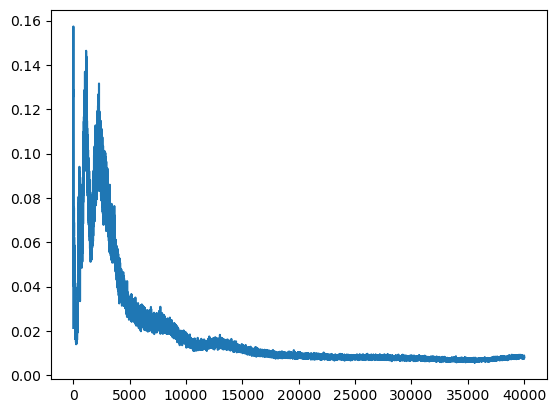

In [8]:
H = avgData_PSD / (avgData_PSD + noiseFFT)
plt.plot(H.abs())

In [9]:
tforms = core.nn.utils.buildTransforms(device = device, 
                                        Fs = Fs, 
                                        n_fft = 800, 
                                        win_length = 800,
                                        hop_length = 160,
                                        n_mels = 80,
                                        f_max_mouse = 8000,
                                        f_max_full = 8000,
                                        )
specFn, inverseSpecFn, melFilterMouse, melFilter, inverseMelFn = tforms

from core.nn.utils import normalize, denormalize
toMelDB = lambda batch: core.nn.utils.toMelDB(batch, specFn=specFn, mousemelfilters=melFilterMouse, fullmelfilter=melFilter)

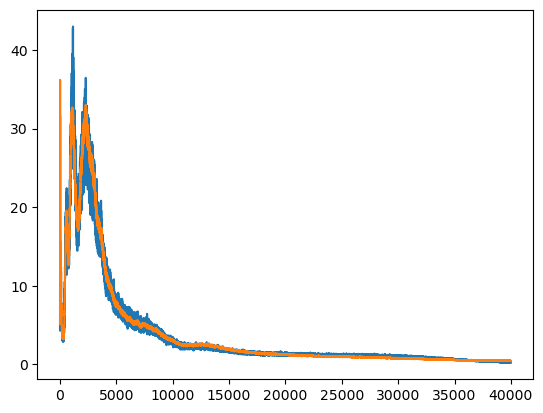

In [10]:
postFiltering = H.abs() * avgNoisy_PSD.abs()
# fft bin to frequency
X = torch.fft.rfftfreq(80000, 1/16000)

# build a dataframe with 4 columns: frequency, avgNoisy, avgData_PSD, postFiltering
df = pd.DataFrame()
df['frequency'] = X
df['avgNoisy'] = avgNoisy_PSD
df['avgData'] = avgData_PSD
df['postFiltering'] = postFiltering
plt.plot(postFiltering)
plt.plot(avgData_PSD)

In [11]:
# save the dataframe
df.to_csv('dataDist.csv', index=False)

In [12]:
batch = next(iter(dev_loader))
M, W = batch
Mfft = torch.fft.rfft(M, dim=2)
Mfiltered = Mfft.mean(dim = 1) * H.to(device).abs() ** 2
Mrecovered = torch.fft.irfft(Mfiltered, dim=1)

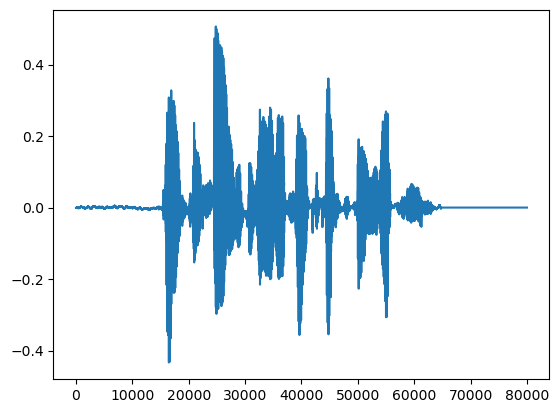

In [13]:
# import ipd and show audios
i = 11
from IPython.display import Audio

plt.plot(W[i, :].cpu())
plt.show()
Audio(W[i, :].cpu(), rate= 16000)

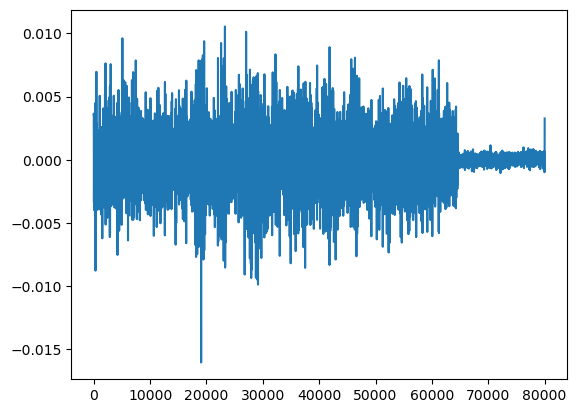

In [14]:
plt.plot(Mrecovered[i, :].cpu())
plt.show()
Audio(Mrecovered[i, :].cpu(), rate= 16000)

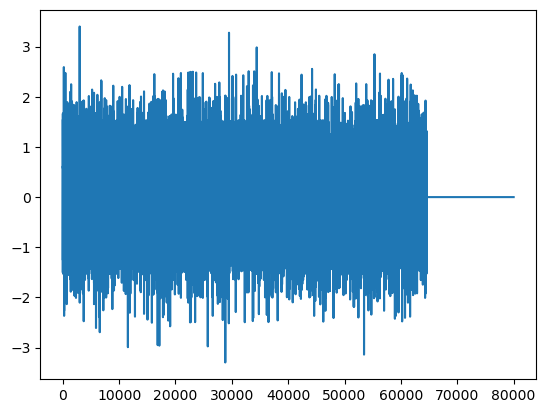

In [15]:
plt.plot(M[i, :, :].mean(dim = 0).cpu())
plt.show()
Audio(M[i, :, :].mean(dim = 0).cpu(), rate= 16000)

In [16]:
def apply_wiener(X, filt = H.to(device)):
    Xfft = torch.fft.rfft(X, dim=-1)
    Yfft = Xfft * filt
    return torch.fft.irfft(Yfft, dim=-1)

In [17]:
# mnmn = torch.inf
# mxmx = -torch.inf
# for Mwav, Wwav in dev_loader:
#     MwavFilt = apply_wiener(Mwav, smoothH.to(device))
#     Mnorm, Wnorm = normalize((MwavFilt, Wwav))
#     Mspec, Wspec, _, _ = toMelDB((Mnorm, Wnorm))
#     Mnofiltspec, _, _, _ = toMelDB((Mwav, Wnorm))
#     mnmn = min(mnmn, Mnofiltspec.min(), Mspec.min(), Wspec.min())
#     mxmx = max(mxmx, Mnofiltspec.max(), Mspec.max(), Wspec.max())
mnmn, mxmx = 0, 2.7663

In [18]:
def mapToBounds(batch):
    M, W = batch
    # remap to [-1, 1]
    W = (W - mnmn) / (mxmx - mnmn)
    M = (M - mnmn) / (mxmx - mnmn)
    W = torch.clamp(W, 0, 1)
    M = torch.clamp(M, 0, 1)
    W = 2 * W - 1
    M = 2 * M - 1
    return  M, W

In [19]:
Mwav, Wwav = next(iter(dev_loader))
MwavFilt = apply_wiener(Mwav, H.to(device))
Mnorm, Wnorm = normalize((MwavFilt, Wwav))
Mspec, Wspec, _, _ = toMelDB((Mnorm, Wnorm))
Mspec, Wspec = mapToBounds((Mspec, Wspec))
Mnofiltspec, _, _, _ = toMelDB((Mwav, Wnorm))
Mnofiltspec, _ = mapToBounds((Mnofiltspec, Wspec))

torch.Size([32, 80, 501])
torch.Size([32, 160, 501])


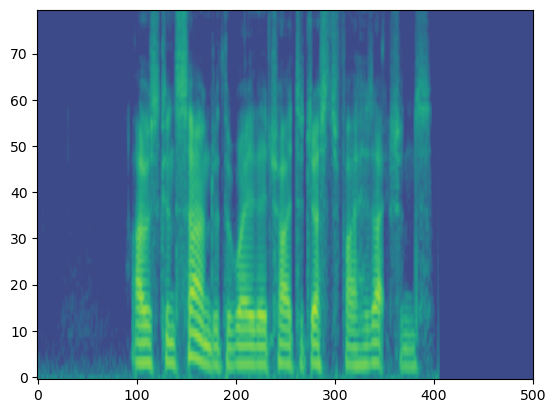

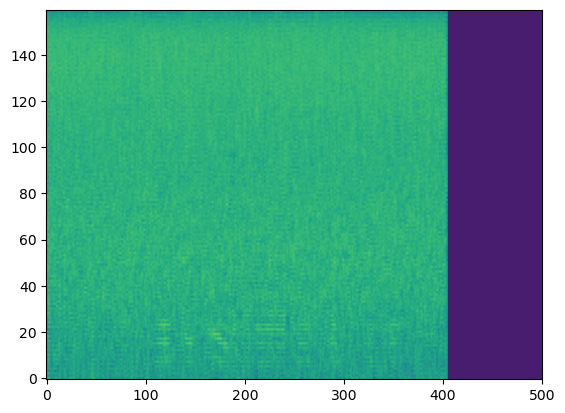

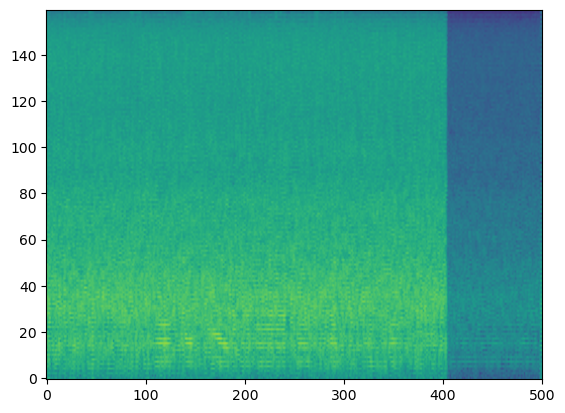

In [20]:
Wspec = Wspec.to(device)
Mspec = Mspec.to(device)
print(Wspec.shape)
print(Mspec.shape)
plt.imshow(Wspec[i, :, :].cpu(), aspect="auto", origin="lower", vmin=-1, vmax=1)
plt.show()
plt.imshow(Mnofiltspec[i, :, :].cpu(), aspect="auto", origin="lower", vmin=-1, vmax=1)
plt.show()
plt.imshow(Mspec[i, :, :].cpu(), aspect="auto", origin="lower", vmin=-1, vmax=1)
plt.show()

In [21]:
# add tiny noise
def perceptModel(X):
    X = F.gelu(perceptualEmbedding.conv1(X))
    X = F.gelu(perceptualEmbedding.conv2(X))
    # X = X.permute(0, 2, 1)
    # X = (X + perceptualEmbedding.positional_embedding).to(X.dtype)
    # X = perceptualEmbedding.blocks[0](X)
    # X = perceptualEmbedding.blocks[1](X)
    # X = perceptualEmbedding.blocks[2](X)
    # X = perceptualEmbedding.blocks[3](X)

    return X

In [ ]:
import torchmetrics
from einops import reduce

computeSNR = torchmetrics.audio.SignalNoiseRatio(Fs).to(device)
computeSTOI= torchmetrics.audio.ShortTimeObjectiveIntelligibility(Fs).to(device)
computePESQ = torchmetrics.audio.PerceptualEvaluationSpeechQuality(Fs, "wb").to(device)
c = 0
SNRfilt = []
SNRbase = []
STOIfilt = []
STOIbase = []
PESQfilt = []
PESQbase = []
with tqdm(total=len(test_loader)) as pbar:
    for i, (Xorig, Yorig) in (enumerate(test_loader)):
        with torch.no_grad():
            Xfilt = apply_wiener(Xorig, H.to(device))
            Xorig = reduce(Xorig, "b c t -> b t", "mean")
            Xfilt = reduce(Xfilt, "b c t -> b t", "mean")
            SNRbase.append(computeSNR(Xorig, Yorig))
            STOIbase.append(computeSTOI(Xorig, Yorig))
            PESQbase.append(computePESQ(Xorig, Yorig))

            # apply wiener filter
            SNRfilt.append(computeSNR(Xfilt, Yorig))
            STOIfilt.append(computeSTOI(Xfilt, Yorig))
            PESQfilt.append(computePESQ(Xfilt, Yorig))
            c += Xorig.shape[0]
            pbar.update(1)
SNRfilt = torch.stack(SNRfilt)
SNRbase = torch.stack(SNRbase)
STOIfilt = torch.stack(STOIfilt)
STOIbase = torch.stack(STOIbase)
PESQfilt = torch.stack(PESQfilt)
PESQbase = torch.stack(PESQbase)
# SNRfilt.mean(), SNRbase.mean(), STOIfilt.mean(), STOIbase.mean(), PESQfilt.mean(), PESQbase.mean()
print(f"SNR: {SNRfilt.mean():.2f}dB (wiener) vs {SNRbase.mean():.2f}dB (baseline), {SNRfilt.mean() - SNRbase.mean():.2f}dB improvement")
print(f"STOI: {STOIfilt.mean():.2f} (wiener) vs {STOIbase.mean():.2f} (baseline), {STOIfilt.mean() - STOIbase.mean():.2f} improvement")
print(f"PESQ: {PESQfilt.mean():.2f} (wiener) vs {PESQbase.mean():.2f} (baseline), {PESQfilt.mean() - PESQbase.mean():.2f} improvement")

In [50]:
from core.nn.whisperPrimitives import *
device = 'cuda' if torch.cuda.is_available() else 'cpu'
embed_d = 384
n_head = 6
n_layer = 4
k_size = 15
padding = k_size // 2
n_mels = 80
model = nn.Sequential(
    nn.Conv1d(n_mels * 2, embed_d, k_size, padding=padding),
    nn.GELU(),
    TransformerChain(n_ctx=501, n_state=embed_d, n_head = n_head, n_layer=n_layer),
    nn.GELU(),
    nn.Conv1d(embed_d, n_mels * 4, k_size, padding=padding),
    nn.GELU(),
    nn.Conv1d(n_mels * 4, n_mels, k_size, padding=padding),
).to(device)

In [51]:
def frobenius_norm(X):
    return torch.sqrt(torch.sum(X ** 2))

def spectral_convergence(X, Y):
    return frobenius_norm(X - Y) / frobenius_norm(Y)

In [53]:
from einops import rearrange
lr = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.707)

l1_loss = nn.L1Loss()
l2_loss = nn.MSELoss()
direct_loss = nn.HuberLoss()
perceptual_loss = lambda x, y: l2_loss(perceptualEmbedding(x), perceptualEmbedding(y))
pad_fn = lambda x, y: (F.pad(x, (0, 3000 - x.shape[-1])), F.pad(y, (0, 3000 - y.shape[-1])))
loss_fn = lambda x, y: (
    # spectral_convergence(x, y)
    # direct_loss(x, y)
    # l2_loss(x, y)
    # perceptual_loss(*pad_fn(x, y)) + 
    direct_loss(x, y) # + spectral_convergence(x, y)
)

def update_model(model, batch):
    model.train()
    optimizer.zero_grad()
    X = batch[0].to(device)
    Y = batch[1].to(device)
    
    # Apply wiener filter
    X = apply_wiener(X, H.to(device))
    X, Y = normalize((X, Y))
    X, Y, _, _ = toMelDB((X, Y))
    X, Y = mapToBounds((X, Y))
    
    recon_batch = model(X)
    loss = loss_fn(recon_batch, Y)
    loss.backward()
    optimizer.step()
    return loss.item()

def train(model, loader, epochs = 10):
    model.train()
    with tqdm(total = epochs * len(loader)) as pbar:
        for epoch in range(epochs):
            for batch_idx, batch in enumerate(loader):
                loss = update_model(model, batch)
                pbar.set_description(f"Epoch {epoch}/{epochs}\tBatch {batch_idx}/{len(loader)}\tLoss {loss}")
                pbar.update(1)
                # wandb.log({"loss": loss}, step = epoch * len(loader) + batch_idx)
            # save model
            scheduler.step()
            torch.save(model.state_dict(), f"model_SUM_E{epoch}_L{loss:.2f}.pt")

In [54]:
train(model, train_loader, epochs = 1)
# torch.save(model.state_dict(), f"model_best.pt")
# model.load_state_dict(torch.load("model_best.pt"))

Epoch 0/1	Batch 229/1129	Loss 0.018897872418165207:  20%|██        | 230/1129 [03:05<12:03,  1.24it/s]


KeyboardInterrupt: 

In [111]:
torch.save(model.state_dict(), "model_newest2.pt")

In [70]:
train(model, train_loader, epochs = 10)

Epoch 9/10	Batch 1128/1129	Loss 0.008842398412525654: 100%|██████████| 11290/11290 [1:54:42<00:00,  1.64it/s]  


C:\Users\mo\AppData\Local\Temp\ipykernel_21072\3759706658.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


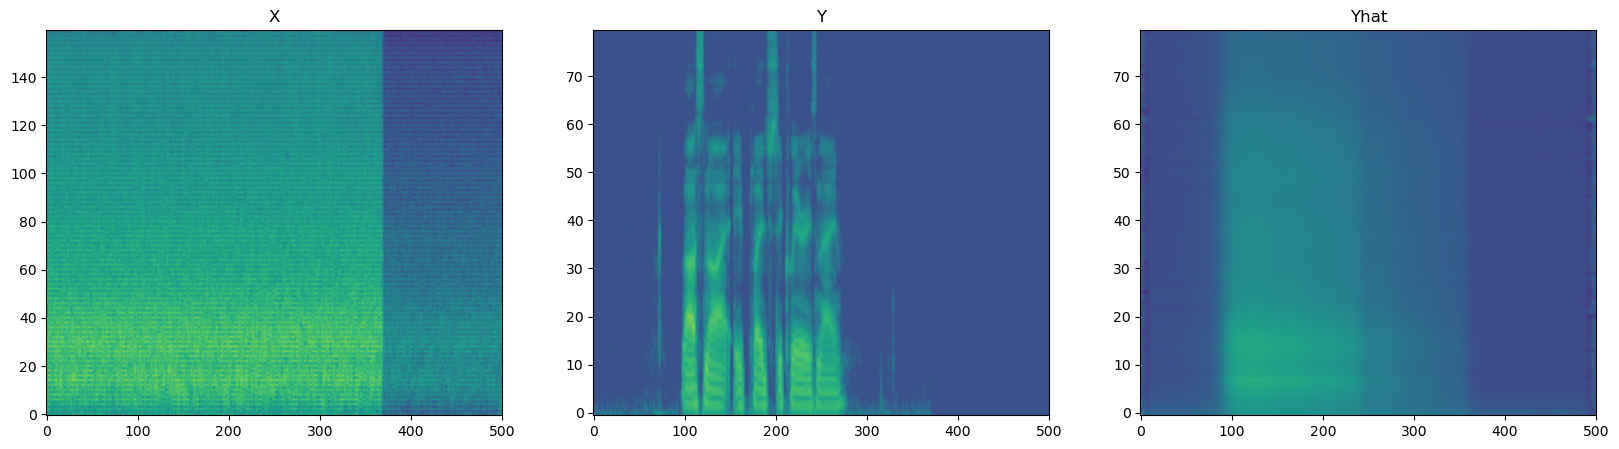

In [55]:
# run one test batch
model.eval()

with torch.no_grad():
    batch = next(iter(test_loader))

    Xorig = batch[0].to(device)
    Yorig = batch[1].to(device)
    # Apply wiener filter
    Xorig = apply_wiener(Xorig, H.to(device))
    Xorig, Yorig = normalize((Xorig, Yorig))
    Xorig, Yorig, _, _ = toMelDB((Xorig, Yorig))
    Xorig, Yorig = mapToBounds((Xorig, Yorig))

    recon_batch = model(Xorig)

    i = 0
    fig, ax = plt.subplots(1, 3, figsize=(20, 5))
    ax[0].imshow(Xorig[i, :, :].cpu().detach(), origin="lower", aspect="auto", vmin=-1, vmax=1)
    ax[0].set_title("X")
    ax[1].imshow(Yorig[i, :, :].cpu().detach(), origin="lower", aspect="auto", vmin=-1, vmax=1)
    ax[1].set_title("Y")
    ax[2].imshow(recon_batch[i, :, :].cpu().detach(), origin="lower", aspect="auto", vmin=-1, vmax=1)
    ax[2].set_title("Yhat")
    fig.show()

In [94]:

with tqdm(total=len(test_loader)) as pbar:
    Xorig, Yorig = next(iter(test_loader))
    with torch.no_grad():
        X = apply_wiener(Xorig, H.to(device))
        X, Y = normalize((X, Yorig))
        X, Y, _, yphase = toMelDB((X, Y))
        X, Y = mapToBounds((X, Y))
        recon_batch = model(X)
        recon_batch = (recon_batch + 1) / 2
        recon_batch = recon_batch * (3 - (-1.5)) + (-1.5)
        recon_batch = recon_batch * 4 - 4
        recon_batch = torch.pow(10, recon_batch)
        recon_batch = inverseMelFn(recon_batch)
        recon_batch = inverseSpecFn(recon_batch)

  0%|          | 0/166 [00:00<?, ?it/s]


In [103]:
import torchmetrics

inverseSpecFn = torchaudio.transforms.GriffinLim(
    n_fft=800,
    win_length=800,
    hop_length=160,
    power=2,
).to(device)

computeSNR = torchmetrics.audio.SignalNoiseRatio(Fs).to(device)
computeSTOI= torchmetrics.audio.ShortTimeObjectiveIntelligibility(Fs).to(device)
computePESQ = torchmetrics.audio.PerceptualEvaluationSpeechQuality(Fs, "wb").to(device)
c = 0
SNRfilt = []
SNRbase = []
STOIfilt = []
STOIbase = []
PESQfilt = []
PESQbase = []
SNRmodel = []
STOImodel = []
PESQmodel = []
with tqdm(total=len(test_loader)) as pbar:
    for i, (Xorig, Yorig) in (enumerate(test_loader)):
        with torch.no_grad():
            Xfilt = apply_wiener(Xorig, H.to(device))
            X, Y = normalize((Xfilt, Yorig))
            X, Y, _, yphase = toMelDB((X, Y))
            X, Y = mapToBounds((X, Y))
            recon_batch = model(X)
            recon_batch = (recon_batch + 1) / 2
            recon_batch = recon_batch * (3 - (-1.5)) + (-1.5)
            recon_batch = recon_batch * 4 - 4
            recon_batch = torch.pow(10, recon_batch)
            recon_batch = inverseMelFn(recon_batch)
            recon_batch = inverseSpecFn(recon_batch)
            recon_batch = denormalize(recon_batch, Yorig)

            SNRmodel.append(computeSNR(recon_batch, Yorig))
            STOImodel.append(computeSTOI(recon_batch, Yorig))
            PESQmodel.append(computePESQ(recon_batch, Yorig))


            Xorig = reduce(Xorig, "b c t -> b t", "mean")
            Xfilt = reduce(Xfilt, "b c t -> b t", "mean")
            SNRbase.append(computeSNR(Xorig, Yorig))
            STOIbase.append(computeSTOI(Xorig, Yorig))
            PESQbase.append(computePESQ(Xorig, Yorig))

            # apply wiener filter
            SNRfilt.append(computeSNR(Xfilt, Yorig))
            STOIfilt.append(computeSTOI(Xfilt, Yorig))
            PESQfilt.append(computePESQ(Xfilt, Yorig))

            print(f"SNR: {SNRfilt[-1]:.2f}dB (wiener) vs {SNRbase[-1]:.2f}dB (baseline), {SNRmodel[-1]:.2f}dB (model)")
            print(f"STOI: {STOIfilt[-1]:.2f} (wiener) vs {STOIbase[-1]:.2f} (baseline), {STOImodel[-1]:.2f} (model)")
            print(f"PESQ: {PESQfilt[-1]:.2f} (wiener) vs {PESQbase[-1]:.2f} (baseline), {PESQmodel[-1]:.2f} (model)")

            c += Xorig.shape[0]
            pbar.update(1)

  1%|          | 1/166 [00:09<25:57,  9.44s/it]

SNR: -2.52dB (wiener) vs -1.44dB (baseline), -1.03dB (model)
STOI: 0.39 (wiener) vs 0.39 (baseline), 0.54 (model)
PESQ: 1.11 (wiener) vs 1.10 (baseline), 1.12 (model)


  1%|          | 2/166 [00:19<27:07,  9.92s/it]

SNR: -2.66dB (wiener) vs -1.59dB (baseline), -1.64dB (model)
STOI: 0.39 (wiener) vs 0.39 (baseline), 0.53 (model)
PESQ: 1.10 (wiener) vs 1.13 (baseline), 1.12 (model)


  2%|▏         | 3/166 [00:29<27:03,  9.96s/it]

...

SNR: -2.70dB (wiener) vs -1.72dB (baseline), -1.00dB (model)
STOI: 0.38 (wiener) vs 0.38 (baseline), 0.52 (model)
PESQ: 1.10 (wiener) vs 1.10 (baseline), 1.12 (model)


 99%|█████████▉| 165/166 [32:20<00:11, 11.91s/it]

SNR: -2.64dB (wiener) vs -1.87dB (baseline), -1.06dB (model)
STOI: 0.40 (wiener) vs 0.40 (baseline), 0.53 (model)
PESQ: 1.10 (wiener) vs 1.10 (baseline), 1.12 (model)


100%|██████████| 166/166 [32:32<00:00, 11.76s/it]

SNR: -2.64dB (wiener) vs -1.72dB (baseline), -1.33dB (model)
STOI: 0.39 (wiener) vs 0.39 (baseline), 0.51 (model)
PESQ: 1.11 (wiener) vs 1.09 (baseline), 1.12 (model)


In [105]:
print(f"SNR: {torch.stack(SNRfilt).mean() * 20:.2f}dB (wiener) vs {torch.stack(SNRbase).mean()  * 20:.2f}dB (baseline), {torch.stack(SNRmodel).mean() * 20:.2f}dB (model)")
print(f"STOI: {torch.stack(STOIfilt).mean():.2f} (wiener) vs {torch.stack(STOIbase).mean():.2f} (baseline), {torch.stack(STOImodel).mean():.2f} (model)")
print(f"PESQ: {torch.stack(PESQfilt).mean():.2f} (wiener) vs {torch.stack(PESQbase).mean():.2f} (baseline), {torch.stack(PESQmodel).mean():.2f} (model)")

SNR: -58.95dB (wiener) vs -38.66dB (baseline), -23.24dB (model)
STOI: 0.39 (wiener) vs 0.39 (baseline), 0.53 (model)
PESQ: 1.12 (wiener) vs 1.11 (baseline), 1.12 (model)


In [110]:
(torch.stack(SNRbase).mean().abs() - torch.stack(SNRfilt).mean().abs())/torch.stack(SNRbase).mean().abs()

tensor(-0.5250, device='cuda:0')